# Try and Render Polygons in ASE; Gonna need projection matrices and shit. Then we're gonna try and create a z_stack that renders atoms and polyhedra in order based on their relative distance away from the camera. May split this into a separate notebook

['Ag', 'Ag', 'Ag', 'Ag', 'I', 'I', 'I', 'I']
[4 4 4 4 4 4 4 4]
[-3.47632058 -2.24157822  7.48723741]
yooo
yooo
yooo
yooo


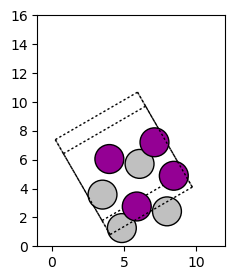

In [ ]:
# -------------------------------------------------------------------- #
# Imports
from matplotlib.patches import Polygon
from ase.neighborlist import neighbor_list
from ase.visualize.plot import plot_atoms
from ase import Atoms
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.spatial import ConvexHull, convex_hull_plot_2d, Delaunay, delaunay_plot_2d
from scipy.spatial.transform import Rotation
from matplotlib.patches import Polygon
from ase.io import read

# -------------------------------------------------------------------- #
# Create supercell, set bounds
#supercell = Atoms(symbols='AgCl', pbc=True, positions=[[0,0,0], [0,2,1.578]], cell=[[-2.001241862062434, 2.001241862062434, 3.1564560000000017], [2.001241862062434, -2.001241862062434, 3.1564560000000017], [2.001241862062434, 2.001241862062434, -3.1564560000000017]])
supercell = read('POSCAR', format='vasp')
supercell = read('/projects/p32212/NewUserIsMe/FreeEnergy_Trials/AgI/Cubic_Tetragonal_PES/ABStrain_0.02/CStrain_0.00/POSCAR', format = 'vasp')

print(supercell.get_chemical_symbols())
supercell.set_pbc([1,1,1])
supercell = supercell.repeat([1,1,1])

supercell.rotate('x',10, center = 'COM', rotate_cell=True)
supercell.rotate('y',0, center = 'COM', rotate_cell=True)
supercell.rotate('z',30, center = 'COM', rotate_cell=True)

# Collect neighborlist according to a cutoff distance:
#bond_cutoff = 3
bond_cutoff = {('Ti', 'O'): 3, ('Sr', 'Ti'): 0.1, ('Sr', 'O'): 0.1}
bond_cutoff = {('Ag', 'I'): 5}

neighs, distances, shift = neighbor_list('iDS', supercell, bond_cutoff, self_interaction=False, max_nbins=1000000.0)
unique_neighs, unique_neigh_counts = np.unique(neighs, return_counts=True)

print(unique_neigh_counts)

# start plotting stuff; gonna need the projection matrices here:
fig, ax = plt.subplots(figsize=(3,3))
#polystack = np.empty((len(unique_neighs),np.max(unique_neigh_counts)))
plot_atoms(supercell, ax, rotation = '0x, 0y, 0z', radii = [1 for atom in supercell])
from ase.io.utils import PlottingVariables
pvars = PlottingVariables(supercell, scale=1.0)
r_vec = pvars.get_camera_right()
u_vec = pvars.get_camera_up()
print(pvars.offset)

for i in np.unique(neighs):
    if supercell.get_chemical_symbols()[i] == 'Ag':
        print('yooo')
    #if i == 4:
        origin = -1 * pvars.offset + supercell.get_positions()[i]
        poly = origin + distances[np.where(neighs == i)[0]]
        vertices = poly
        
        hull = ConvexHull(vertices)

        for e_ind, edge in enumerate(vertices[hull.simplices]):
            # project 3D coords into 2D based on some temporary image plane and basis:
            projection_plane_origin = [0,0,0] #distances[0] # set at closest atom for real
            projection_plane_basis = np.array([r_vec,u_vec])

            points_2D = projection_plane_basis @ (edge.T - projection_plane_origin)
            ax.add_patch(Polygon(xy = points_2D.T,
                            facecolor = 'grey',
                            edgecolor = 'black',
                            alpha = 0.2))

ax.set_xlim(-1, 12)
ax.set_ylim(0, 16)

plt.show()

In [2]:
print(supercell.get_center_of_mass())

[1.62406329 1.62406329 3.06274086]


# 3D to 2D Projection Trial

In [ ]:
points_3D = np.array([[1,0,0],[0,1,0],[0,0,1]])

projection_plane_origin = [-1,-1,-1]
projection_plane_basis = np.array([[1,-1,0],[0,0,1]])

points_2D = projection_plane_basis @ (points_3D - projection_plane_origin)

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(xs = points_3D[:,0], ys = points_3D[:,1], zs = points_3D[:,2])
ax.view_init(elev=45., azim=-45, roll=0)

fig, ax = plt.subplots()
print(points_2D)
ax.scatter(points_2D[0,:], points_2D[1,:])

In [ ]:
fig, ax = plt.subplots(figsize = (3,3))
ax.add_patch(Polygon(xy = points_2D.T,
                            facecolor = 'grey',
                            edgecolor = 'black',
                            alpha = 0.2,))
ax.set_xlim(-2,2)
ax.set_ylim(0,2)

# Build Nucleation Graphic for Qual

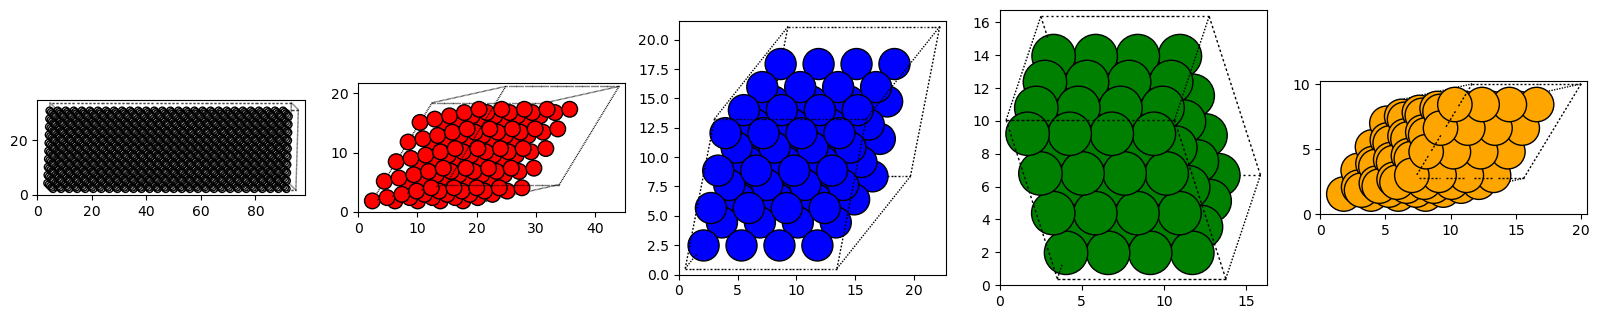

In [2]:
# Default
import matplotlib.pyplot as plt
import numpy as np
# MPL extras
from matplotlib.colors import to_rgba, to_rgb
# Mine
from DFTUtils import render_povray
# ASE
from ase.build import bulk
from ase.visualize.plot import plot_atoms

# ----------------------------------- #
# Colors
grey = np.concatenate((to_rgb('grey'), [0.1]))
red = np.concatenate((to_rgb('red'), [1]))
blue = np.concatenate((to_rgb('blue'), [1]))
green = np.concatenate((to_rgb('green'), [1]))
orange = np.concatenate((to_rgb('orange'), [1]))

# ----------------------------------- #
# Define matrix
matrix = bulk('Fe', crystalstructure='sc', a=3)
matrix = matrix.repeat((30,10,5))
matrix.set_tags(1)

matrix_colors = [grey for atom in matrix]

# ----------------------------------- #
# Define nucleus 1
nucleus_1 = bulk('Fe', crystalstructure='fcc', a=5.5)
nucleus_1.set_cell(nucleus_1.cell.standard_form()[0], scale_atoms=True)
nucleus_1 = nucleus_1.repeat((5,5,5))

nucleus_1_colors = [red for atom in nucleus_1]

# ----------------------------------- #
# Define nucleus 2
nucleus_2 = bulk('Fe', crystalstructure='bct', a=3, c = 5)
nucleus_2.set_cell(nucleus_2.cell.standard_form()[0], scale_atoms=True)
nucleus_2 = nucleus_2.repeat((4,4,4))

nucleus_2_colors = [blue for atom in nucleus_2]

# ----------------------------------- #
# Define nucleus 3
nucleus_3 = bulk('Fe', crystalstructure='bcc', a=3, c = 5)
nucleus_3.set_cell(nucleus_3.cell.standard_form()[0], scale_atoms=True)
nucleus_3 = nucleus_3.repeat((4,4,4))

nucleus_3_colors = [green for atom in nucleus_3]

# ----------------------------------- #
# Define nucleus 4
nucleus_4 = bulk('Fe', crystalstructure='diamond', a=3)
nucleus_4.set_cell(nucleus_4.cell.standard_form()[0], scale_atoms=True)
nucleus_4 = nucleus_4.repeat((4,4,4))

nucleus_4_colors = [orange for atom in nucleus_4]

# ----------------------------------- #
# Set Structures
structures = [matrix, nucleus_1, nucleus_2, nucleus_3, nucleus_4]

# -------------- #
# matrix color/radii settings
colors = [matrix_colors, nucleus_1_colors, nucleus_2_colors, nucleus_3_colors, nucleus_4_colors]

fig, axes = plt.subplots(1, len(structures), figsize = (4 * len(structures), 5))
for ind, ax in enumerate(axes):
    plot_atoms(structures[ind], ax, rotation = '10x,10y,0z', colors = colors[ind])

<Axes: >

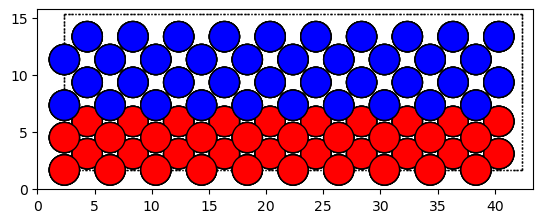

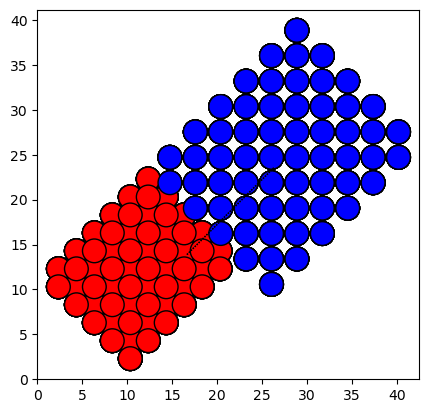

In [63]:
from ase.build import fcc110, bcc100, stack

surf_1 = fcc110('Fe', (10,2,10), a=4, vacuum=None)
surf_1.set_tags(1)

surf_2 = bcc100('Fe', (10,2,10), a=4, vacuum=None)
surf_2.set_tags(2)

stacked_surfaces = stack(surf_1, surf_2, axis = 1)
cell = stacked_surfaces.cell[:]

colors = ['red' if atom.tag == 1 else 'blue' for atom in stacked_surfaces]

fig, ax = plt.subplots()
plot_atoms(stacked_surfaces, ax, colors = colors)

# ----------------------------------------------------- #
# ruh i hate it here

surf_1 = fcc110('Fe', (10,6,10), a=4, vacuum=None)
surf_1.set_tags(1)

surf_2 = bcc100('Fe', (10,6,10), a=4, vacuum=None)
surf_2.set_tags(2)

stacked_surfaces = stack(surf_1, surf_2, axis = 1)

stacked_surfaces.set_cell(cell)
stacked_surfaces.center()
# stacked_surfaces.rotate([1,0,1], [0,0,1], center = 'cou')

# print(np.where(np.any(stacked_surfaces.get_scaled_positions() > 1)))

# del stacked_surfaces[np.any(stacked_surfaces.get_scaled_positions() > 1, axis = 1)]
# del stacked_surfaces[np.any(stacked_surfaces.get_scaled_positions() < 0, axis = 1)]

colors = ['red' if atom.tag == 1 else 'blue' for atom in stacked_surfaces]

fig, ax = plt.subplots()
plot_atoms(stacked_surfaces, ax, colors = colors, rotation = '90x,90y,45z')

In [43]:
print(np.any(stacked_surfaces.get_scaled_positions() > 1, axis = 1))
print(stacked_surfaces.get_scaled_positions())

[False False False ...  True  True  True]
[[ 0.05        0.0732233   1.        ]
 [ 0.15        0.0732233   1.        ]
 [ 0.25        0.0732233   1.        ]
 ...
 [ 0.7         0.98223305 38.87005769]
 [ 0.8         0.98223305 38.87005769]
 [ 0.9         0.98223305 38.87005769]]


In [22]:
def replace_sphere_of_atoms(matrix, nucleus, scaled_center, scaled_radius, nucleus_tag = 2, nucleus_rotation = None):
    """
    matrix (ASE atoms): atomic structure of matrix
    nucleus (ASE atoms): atomic structure of nucleus
    scaled_center (float, float, float): scaled x y z coords of nucleus
    scaled_radius (float): scaled radius
    """

    # ------------------------------------------------------ #
    assert scaled_radius < 1

    cell_dims = matrix.cell.cellpar()[:3]
    actual_radius = np.max(cell_dims) * scaled_radius
    actual_positions = scaled_center * cell_dims

    # -------------------------- #
    # Delete atoms within the sphere from the matrix:
    matrix_positions = matrix.get_scaled_positions()
    print(matrix_positions)
    matrix_sphere = np.sum((matrix_positions - scaled_center)**2, axis = 1)
    print(matrix_sphere)
    matrix_atoms_in_sphere = matrix_sphere < scaled_radius**2
    print(matrix_atoms_in_sphere)

    del matrix[matrix_atoms_in_sphere]

    # -------------------------- #
    # Set scale of radius in nucleus coordinates - we can always take from the center of the nucleus
    nucleus_positions = nucleus.get_positions()
    nucleus_sphere = np.sum((nucleus_positions - nucleus.get_center_of_mass())**2, axis = 1)
    nucleus_atoms_out_of_sphere = nucleus_sphere > actual_radius**2

    del nucleus[nucleus_atoms_out_of_sphere]
    nucleus.set_tags(nucleus_tag)

    # --------------------------- #
    # Locate COM of nucleus and shift it to scaled_center
    center = nucleus.get_center_of_mass()
    nucleus.set_cell(matrix.cell[:])
    nucleus.center(about=scaled_center * matrix.cell.cellpar()[:3])

    return matrix, nucleus

print(len(matrix))
replace_sphere_of_atoms(matrix, nucleus_1, scaled_center=(0.15,0.35,0.5), scaled_radius=0.12, nucleus_tag = 2)
print(len(matrix))

replace_sphere_of_atoms(matrix, nucleus_2, scaled_center=(0.8,0.6,0.5), scaled_radius = 0.08, nucleus_tag = 3)
replace_sphere_of_atoms(matrix, nucleus_3, scaled_center=(0.35,0.7,0.5), scaled_radius = 0.1, nucleus_tag = 4)
replace_sphere_of_atoms(matrix, nucleus_4, scaled_center=(0.85,0.15,0.6), scaled_radius = 0.1, nucleus_tag = 5)

1454
[[0.         0.         0.        ]
 [0.         0.         0.2       ]
 [0.         0.         0.4       ]
 ...
 [0.96666667 0.9        0.4       ]
 [0.96666667 0.9        0.6       ]
 [0.96666667 0.9        0.8       ]]
[0.395      0.235      0.155      ... 0.97944444 0.97944444 1.05944444]
[False False False ... False False False]
1454
[[0.         0.         0.        ]
 [0.         0.         0.2       ]
 [0.         0.         0.4       ]
 ...
 [0.96666667 0.9        0.4       ]
 [0.96666667 0.9        0.6       ]
 [0.96666667 0.9        0.8       ]]
[1.25       1.09       1.01       ... 0.12777778 0.12777778 0.20777778]
[False False False ... False False False]
[[0.         0.         0.        ]
 [0.         0.         0.2       ]
 [0.         0.         0.4       ]
 ...
 [0.96666667 0.9        0.4       ]
 [0.96666667 0.9        0.6       ]
 [0.96666667 0.9        0.8       ]]
[0.8625     0.7025     0.6225     ... 0.43027778 0.43027778 0.51027778]
[False False False ... F

(Atoms(symbols='Fe1446', pbc=True, cell=[90.0, 30.0, 15.0], tags=...),
 Atoms(symbols='Fe64', pbc=True, cell=[90.0, 30.0, 15.0], tags=...))

<Axes: >

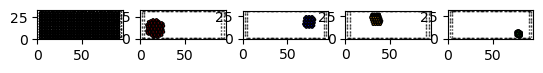

In [23]:
# -------------------------------------------- #
# Matrix
fig, axes = plt.subplots(1,len(structures))
matrix_colors = [grey for atom in matrix]
plot_atoms(matrix, axes[0], colors = matrix_colors, rotation = '0x,0y,0z')

# -------------------------------------------- #
# Nucleus 1
nucleus_1_colors = [red for atom in nucleus_1]
plot_atoms(nucleus_1, axes[1], colors = nucleus_1_colors, rotation = '0x,10y,0z')

# -------------------------------------------- #
# Nucleus 2
nucleus_2_colors = [blue for atom in nucleus_2]
plot_atoms(nucleus_2, axes[2], colors = nucleus_2_colors, rotation = '0x,10y,0z')

# -------------------------------------------- #
# Nucleus 3
nucleus_3_colors = [orange for atom in nucleus_3]
plot_atoms(nucleus_3, axes[3], colors = nucleus_3_colors, rotation = '0x,10y,0z')

# -------------------------------------------- #
# Nucleus 4
nucleus_4_colors = [green for atom in nucleus_4]
plot_atoms(nucleus_4, axes[4], colors = nucleus_4_colors, rotation = '0x,10y,0z')

[[  76 1449]
 [ 106 1470]
 [ 107 1470]
 ...
 [1695 1696]
 [1695 1697]
 [1696 1697]]
Atoms(symbols='Fe1397', pbc=True, cell=[90.0, 30.0, 15.0], initial_magmoms=..., tags=...)


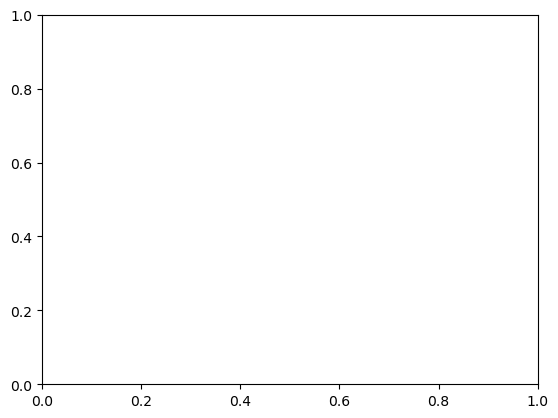

In [24]:
from ase.geometry import get_duplicate_atoms
from ase.data import covalent_radii

fig, ax = plt.subplots()

union = matrix + nucleus_1 + nucleus_2 + nucleus_3 + nucleus_4

print(get_duplicate_atoms(union, cutoff = 1.65 * covalent_radii[25], delete=True))
print(union)

colors = np.array(range(len(union)), dtype = 'object')
for ind, atom in enumerate(union):
    if atom.tag == 1:
        colors[ind] = grey
    elif atom.tag == 2:
        colors[ind] = red
    elif atom.tag == 3:
        colors[ind] = blue
    elif atom.tag == 4:
        colors[ind] = orange
    elif atom.tag == 5:
        colors[ind] = green

#plot_atoms(union, ax, rotation = '0x,0y,0z', colors = colors)

povray_settings = {  # For povray files only
        'transparent': True,  # Transparent background
        'canvas_width': 800,  # Width of canvas in pixels
        'textures': ['jmol' for atom in union], # jmol aight, ase2 ase3 good, 
        'transmittances': [0.45 if atom.tag == 1 else 0 for atom in union]
    }

render_povray('render', union, {'colors': colors, 'rotation': '2x,2y,0z'}, povray_settings=povray_settings, bonds = False)

# Nucleation with an amorphous border

In [20]:
# Default
import matplotlib.pyplot as plt
import numpy as np
# MPL extras
from matplotlib.colors import to_rgba, to_rgb
# Mine
from DFTUtils import render_povray
# ASE
from ase.build import bulk
from ase.visualize.plot import plot_atoms

# ----------------------------------- #
# Colors
grey = np.concatenate((to_rgb('grey'), [0.1]))
red = np.concatenate((to_rgb('red'), [1]))
blue = np.concatenate((to_rgb('blue'), [1]))
green = np.concatenate((to_rgb('green'), [1]))
orange = np.concatenate((to_rgb('orange'), [1]))

# ----------------------------------- #
# Define matrix
matrix = bulk('Fe', crystalstructure='sc', a=3)
matrix = matrix.repeat((10,10,4))
matrix.set_tags(1)

matrix_colors = [grey for atom in matrix]

# ----------------------------------- #
# Define nucleus 1
nucleus_1 = bulk('Fe', crystalstructure='fcc', a=5.5)
nucleus_1.set_cell(nucleus_1.cell.standard_form()[0], scale_atoms=True)
nucleus_1 = nucleus_1.repeat((10,10,4))

nucleus_1_colors = [red for atom in nucleus_1]

# ----------------------------------- #
# Define nucleus 2
nucleus_2 = bulk('Fe', crystalstructure='bct', a=3, c = 5)
nucleus_2.set_cell(nucleus_2.cell.standard_form()[0], scale_atoms=True)
nucleus_2 = nucleus_2.repeat((10,10,4))

nucleus_2_colors = [blue for atom in nucleus_2]

nucleus_2_copy = nucleus_2.copy()

# ----------------------------------- #
# Set Structures
structures = [matrix, nucleus_1, nucleus_2]

# -------------- #
# matrix color/radii settings
colors = [matrix_colors, nucleus_1_colors, nucleus_2_colors]

# fig, axes = plt.subplots(1, len(structures), figsize = (4 * len(structures), 5))
# for ind, ax in enumerate(axes):
#     plot_atoms(structures[ind], ax, rotation = '10x,10y,0z', colors = colors[ind])

nucleus_1 = matrix.copy()
nucleus_2 = matrix.copy()

<Axes: >

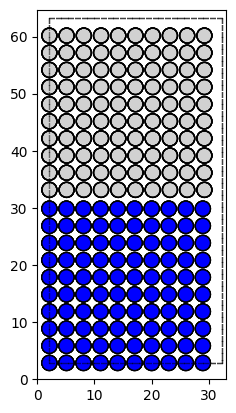

In [21]:
from ase.build import stack

nucleus_1.set_cell(nucleus_1.cell.standard_form()[0] * np.array([1.01,1.01,1.01]))
matrix.set_tags(1)
nucleus_1.set_tags(2)

union = stack(nucleus_1, matrix , axis = 1, maxstrain = 10)

colors = [grey if atom.tag == 1 else blue for atom in union]
fig, ax = plt.subplots()
plot_atoms(union, ax, colors = colors)

In [3]:
def replace_sphere_of_atoms(matrix, nucleus, scaled_center, scaled_radius, nucleus_tag = 2, nucleus_rotation = None, rattle_nucleus = (False, 0.001)):
    """
    matrix (ASE atoms): atomic structure of matrix
    nucleus (ASE atoms): atomic structure of nucleus
    scaled_center (float, float, float): scaled x y z coords of nucleus
    scaled_radius (float): scaled radius
    """

    # ------------------------------------------------------ #
    assert scaled_radius < 1

    cell_dims = matrix.cell.cellpar()[:3]
    actual_radius = np.max(cell_dims) * scaled_radius
    actual_positions = scaled_center * cell_dims

    # -------------------------- #
    # Delete atoms within the sphere from the matrix:
    matrix_positions = matrix.get_scaled_positions()
    print(matrix_positions)
    matrix_sphere = np.sum((matrix_positions - scaled_center)**2, axis = 1)
    print(matrix_sphere)
    matrix_atoms_in_sphere = matrix_sphere < scaled_radius**2
    print(matrix_atoms_in_sphere)

    del matrix[matrix_atoms_in_sphere]

    # -------------------------- #
    # Set scale of radius in nucleus coordinates - we can always take from the center of the nucleus
    nucleus_positions = nucleus.get_positions()
    nucleus_sphere = np.sum((nucleus_positions - nucleus.get_center_of_mass())**2, axis = 1)
    nucleus_atoms_out_of_sphere = nucleus_sphere > actual_radius**2

    del nucleus[nucleus_atoms_out_of_sphere]
    nucleus.set_tags(nucleus_tag)
    if rattle_nucleus[0] == True:
        nucleus.rattle(rattle_nucleus[1])

    # --------------------------- #
    # Locate COM of nucleus and shift it to scaled_center
    center = nucleus.get_center_of_mass()
    nucleus.set_cell(matrix.cell[:])
    nucleus.center(about=scaled_center * matrix.cell.cellpar()[:3])

    return matrix, nucleus

replace_sphere_of_atoms(matrix, nucleus_1, scaled_center=(0.5,0.5,0.5), scaled_radius = 0.2, nucleus_tag = 3, rattle_nucleus = (True, 0.001))

[[0.   0.   0.  ]
 [0.   0.   0.25]
 [0.   0.   0.5 ]
 ...
 [0.9  0.9  0.25]
 [0.9  0.9  0.5 ]
 [0.9  0.9  0.75]]
[0.75   0.5625 0.5    0.5625 0.66   0.4725 0.41   0.4725 0.59   0.4025
 0.34   0.4025 0.54   0.3525 0.29   0.3525 0.51   0.3225 0.26   0.3225
 0.5    0.3125 0.25   0.3125 0.51   0.3225 0.26   0.3225 0.54   0.3525
 0.29   0.3525 0.59   0.4025 0.34   0.4025 0.66   0.4725 0.41   0.4725
 0.66   0.4725 0.41   0.4725 0.57   0.3825 0.32   0.3825 0.5    0.3125
 0.25   0.3125 0.45   0.2625 0.2    0.2625 0.42   0.2325 0.17   0.2325
 0.41   0.2225 0.16   0.2225 0.42   0.2325 0.17   0.2325 0.45   0.2625
 0.2    0.2625 0.5    0.3125 0.25   0.3125 0.57   0.3825 0.32   0.3825
 0.59   0.4025 0.34   0.4025 0.5    0.3125 0.25   0.3125 0.43   0.2425
 0.18   0.2425 0.38   0.1925 0.13   0.1925 0.35   0.1625 0.1    0.1625
 0.34   0.1525 0.09   0.1525 0.35   0.1625 0.1    0.1625 0.38   0.1925
 0.13   0.1925 0.43   0.2425 0.18   0.2425 0.5    0.3125 0.25   0.3125
 0.54   0.3525 0.29   0.3525 0.45 

(Atoms(symbols='Fe389', pbc=True, cell=[30.0, 30.0, 12.0], tags=...),
 Atoms(symbols='Fe32', pbc=True, cell=[30.0, 30.0, 12.0], tags=...))

[]
Atoms(symbols='Fe421', pbc=True, cell=[30.0, 30.0, 12.0], tags=...)


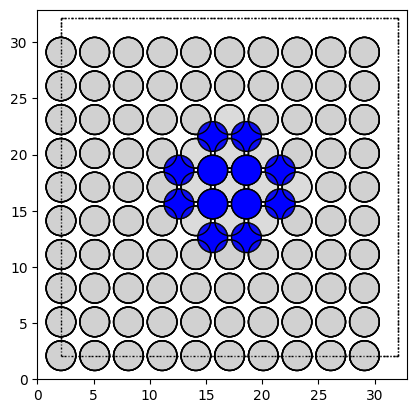

In [4]:
from ase.geometry import get_duplicate_atoms
from ase.data import covalent_radii

fig, ax = plt.subplots()

union = matrix + nucleus_1
print(get_duplicate_atoms(union, cutoff = 1.65 * covalent_radii[25], delete=True))
print(union)

colors = np.array(range(len(union)), dtype = 'object')
for ind, atom in enumerate(union):
    if atom.tag == 1:
        colors[ind] = grey
    elif atom.tag == 2:
        colors[ind] = red
    elif atom.tag == 3:
        colors[ind] = blue
    elif atom.tag == 4:
        colors[ind] = orange
    elif atom.tag == 5:
        colors[ind] = green

plot_atoms(union, ax, rotation = '0x,0y,0z', colors = colors)

povray_settings = {  # For povray files only
        'transparent': True,  # Transparent background
        'canvas_width': 800,  # Width of canvas in pixels
        'textures': ['jmol' for atom in union], # jmol aight, ase2 ase3 good, 
        'transmittances': [0.45 if atom.tag == 1 else 0 for atom in union]
    }

render_povray('render', union, {'colors': colors, 'rotation': '2x,2y,0z'}, povray_settings=povray_settings, bonds = False)

# Free Energy Landscape

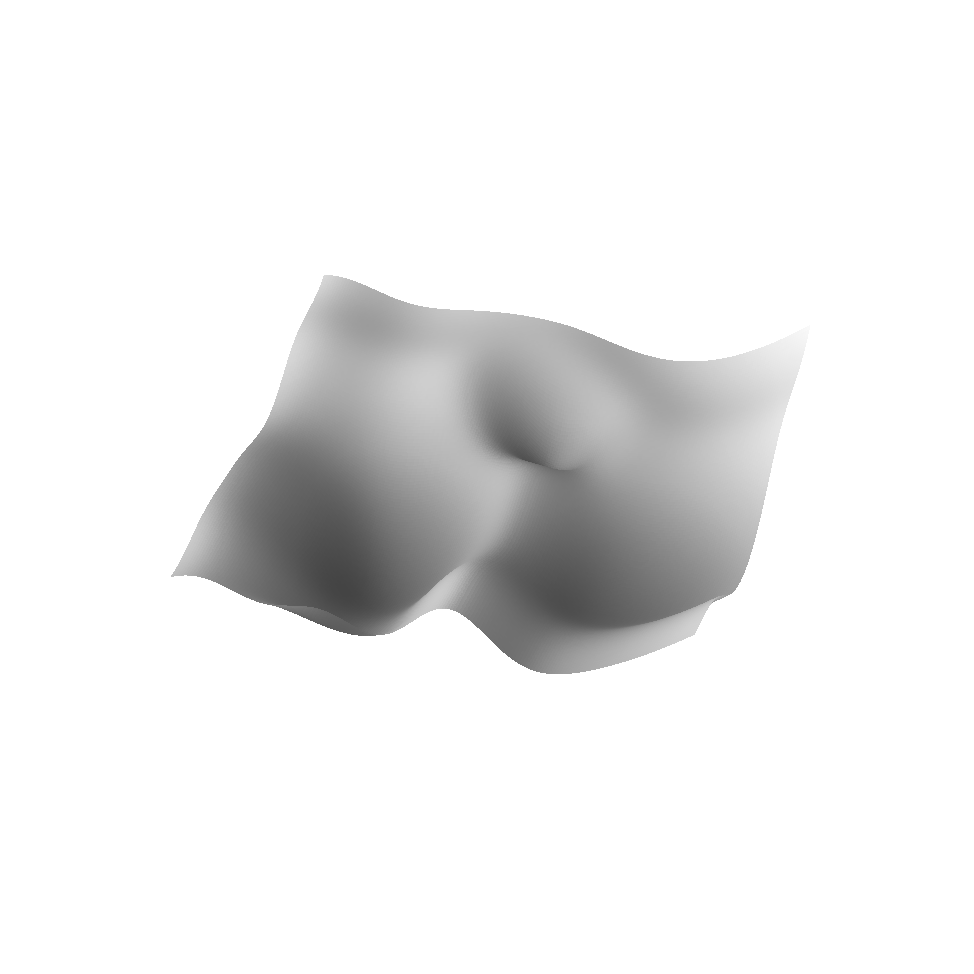

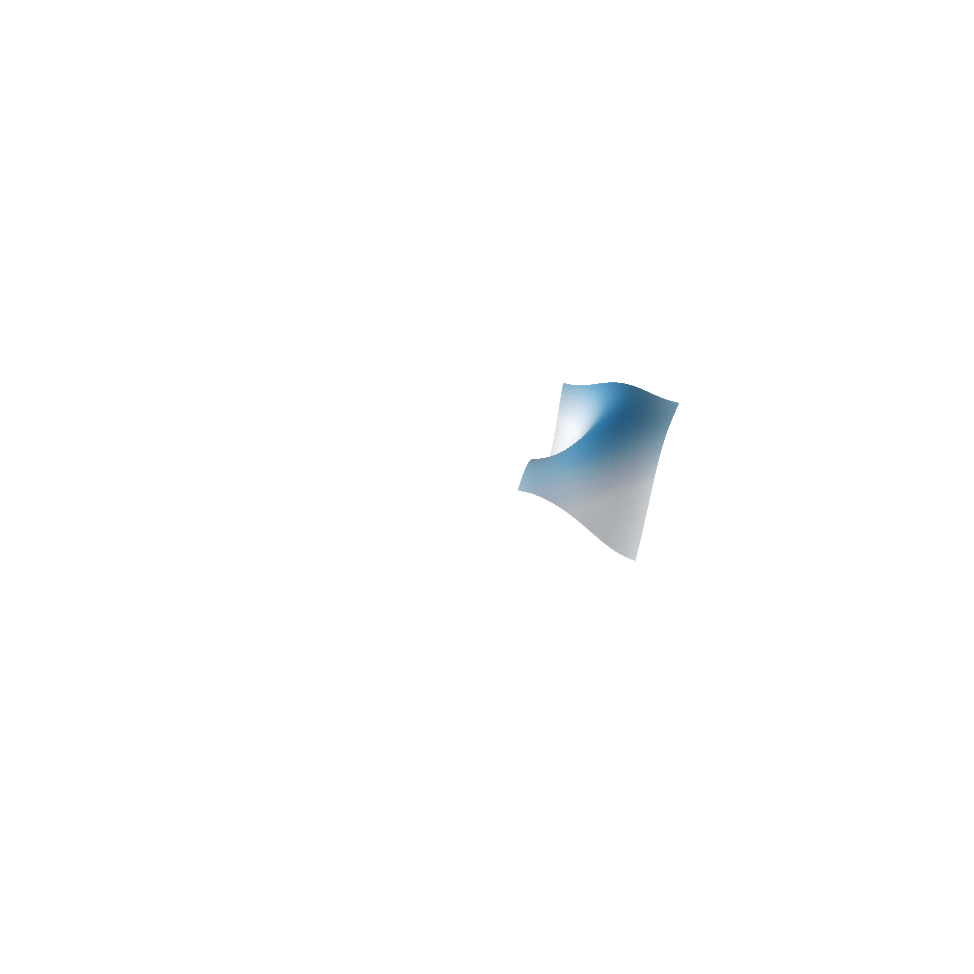

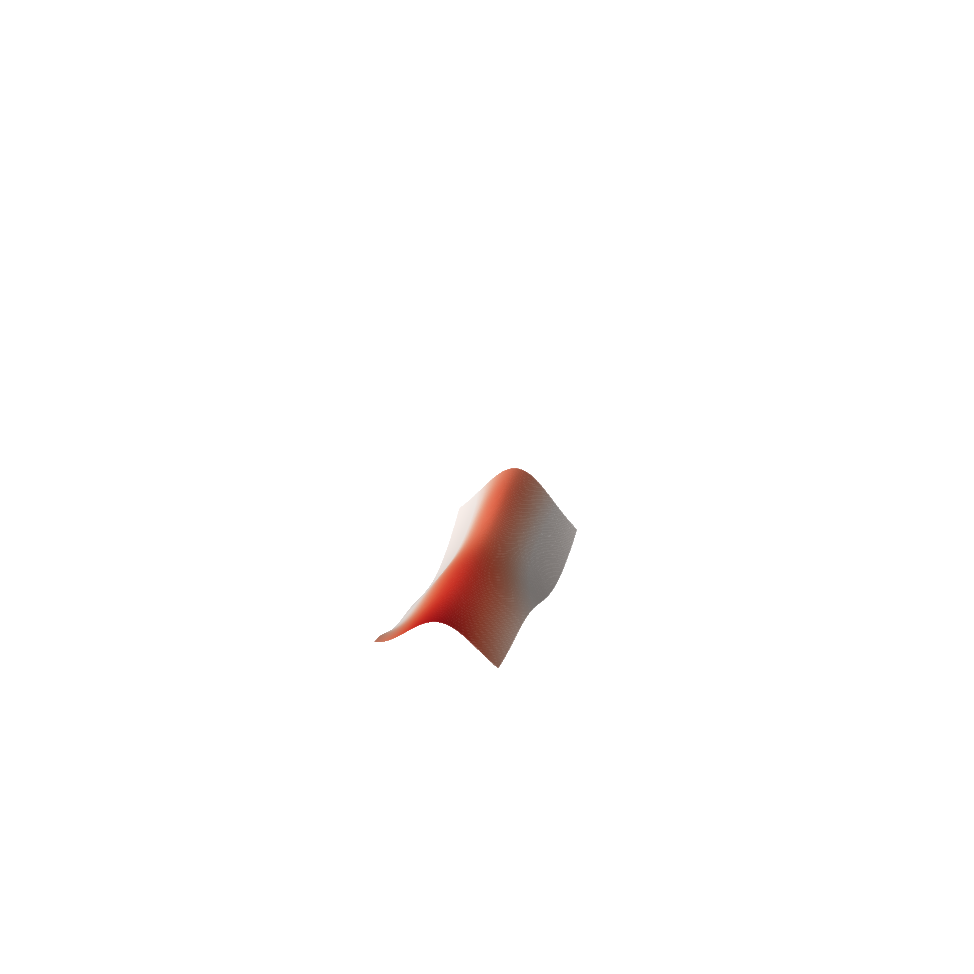

In [186]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rcParams['figure.dpi'] = 250

def gaussian_ridge(x, y, f, a, b, c, center):
    result = f * np.exp(-1/2 * ((x - center[0])**2 + 2 * b * (x - center[0]) * (y - center[1]) + c * (y - center[1])))
    return result

def gaussian_reg(x,y,f,x_spread,y_spread, center):
    x_portion = -1 * ((x-center[0])/(2 * x_spread))**2
    y_portion = -1 * ((y-center[1])/(2 * y_spread))**2
    result = f * np.exp(x_portion + y_portion)

    return result

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# ------------------------------------------------------------------- #
# SECOND PLOT
x = np.linspace(-2.5, 6, 1000)
y = np.linspace(-3.5, 5, 1000)
X, Y = np.meshgrid(x, y)

Z = (gaussian_reg(X,Y,0.5,3,3,(0,0)) + # hump - north right
    
    gaussian_reg(X,Y,2,1,2,(2,2)) + # hump - north right
    gaussian_reg(X,Y,2,1,2,(0,4)) + # hump - north right
    gaussian_reg(X,Y,-2.5,0.5,0.5,(2,3)) + # hump - north right
    gaussian_reg(X,Y,2,1,1,(-3,0)) + # hump - north right
     

     gaussian_reg(X,Y,2.5,0.5,1,(-5,0)) + # hump - due lef
     gaussian_reg(Y,X,2,3,0.5,(-4,2)) + # hump - due left
     gaussian_reg(Y,X,1,1,4,(-4,0)) + # hump - due left
     gaussian_reg(Y,X,2,0.5,0.5,(-4,0)) + # hump - due left

    gaussian_ridge(X,Y,2,0.05,0.05,0.05,(-2,-3)) +
    gaussian_ridge(Y,X,1,0.02,0.02,0.02,(-2,0)) +
    #gaussian_ridge(Y,X,1,0.05,0.05,0.05,(-3,1.5)) +
    gaussian_ridge(Y,X,1,0.05,0.05,0.05,(3,1.5)) +
    
    10/100 *(X**2 + Y**2)
    )

cmap = cm.Greys_r
norm = Normalize(vmin = 0, vmax=Z.max())
surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), alpha = 1, linewidth=0, antialiased=False, rstride = 5, cstride = 5)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
zlim = (0,10)
ax.set_zlim(zlim)
ax.view_init(35,-75,0)
ax.axis('off')
plt.savefig('unmodified.png')

# ------------------------------------------------------------------- #
# SECOND PLOT
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = np.linspace(2, 4, 1000)
y = np.linspace(1, 4, 1000)
X, Y = np.meshgrid(x, y)

Z = (gaussian_reg(X,Y,0.5,3,3,(0,0)) + # hump - north right
    
    gaussian_reg(X,Y,2,1,2,(2,2)) + # hump - north right
    gaussian_reg(X,Y,2,1,2,(0,4)) + # hump - north right
    gaussian_reg(X,Y,-2.5,0.5,0.5,(2,3)) + # hump - north right
    gaussian_reg(X,Y,2,1,1,(-3,0)) + # hump - north right

    # NEW
    gaussian_reg(X,Y,1,0.35,0.75,(3,2.5)) + # hump - north right
    #gaussian_reg(X,Y,1.5,5,5,(0,0)) +
     

     gaussian_reg(X,Y,2.5,0.5,1,(-5,0)) + # hump - due lef
     gaussian_reg(Y,X,2,3,0.5,(-4,2)) + # hump - due left
     gaussian_reg(Y,X,1,1,4,(-4,0)) + # hump - due left
     gaussian_reg(Y,X,2,0.5,0.5,(-4,0)) + # hump - due left

    gaussian_ridge(X,Y,2,0.05,0.05,0.05,(-2,-3)) +
    gaussian_ridge(Y,X,1,0.02,0.02,0.02,(-2,0)) +
    #gaussian_ridge(Y,X,1,0.05,0.05,0.05,(-3,1.5)) +
    gaussian_ridge(Y,X,1,0.05,0.05,0.05,(3,1.5)) +
    
    10/100 *(X**2 + Y**2)
    )

cmap = cm.Blues
norm = Normalize(vmin = Z.min() + 1, vmax=Z.max() + 0.5)
surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), alpha = 0.5, linewidth=0, antialiased=False, rstride = 5, cstride = 5)
ax.view_init(35,-75,0)
ax.axis('off')
ax.set_zlim(zlim)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.savefig('modified_2.png', transparent = True)

# ------------------------------------------------------------------- #
# SECOND PLOT
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = np.linspace(1, 3, 1000)
y = np.linspace(-4, 1, 1000)
X, Y = np.meshgrid(x, y)

Z = (gaussian_reg(X,Y,0.5,3,3,(0,0)) + # hump - north right
    
    gaussian_reg(X,Y,2,1,2,(2,2)) + # hump - north right
    gaussian_reg(X,Y,2,1,2,(0,4)) + # hump - north right
    gaussian_reg(X,Y,-2.5,0.5,0.5,(2,3)) + # hump - north right
    gaussian_reg(X,Y,2,1,1,(-3,0)) + # hump - north right

    # NEW
    gaussian_reg(X,Y,1,0.35,0.75,(2,0)) + # hump - north right
    #gaussian_reg(X,Y,1.5,5,5,(0,0)) +
     

     gaussian_reg(X,Y,2.5,0.5,1,(-5,0)) + # hump - due lef
     gaussian_reg(Y,X,2,3,0.5,(-4,2)) + # hump - due left
     gaussian_reg(Y,X,1,1,4,(-4,0)) + # hump - due left
     gaussian_reg(Y,X,2,0.5,0.5,(-4,0)) + # hump - due left

    gaussian_ridge(X,Y,2,0.05,0.05,0.05,(-2,-3)) +
    gaussian_ridge(Y,X,1,0.02,0.02,0.02,(-2,0)) +
    #gaussian_ridge(Y,X,1,0.05,0.05,0.05,(-3,1.5)) +
    gaussian_ridge(Y,X,1,0.05,0.05,0.05,(3,1.5)) +
    
    10/100 *(X**2 + Y**2)
    )

cmap = cm.Reds
norm = Normalize(vmin = Z.min() + 1, vmax=Z.max() + 0.5)
surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), alpha = 0.5, linewidth=0, antialiased=False, rstride = 5, cstride = 5)
ax.view_init(35,-75,0)
ax.axis('off')
ax.set_zlim(zlim)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.savefig('modified.png', transparent = True)